In [1]:
'''
Aim: Differential gene analysis by DESeq on pseudo-bulk parse data
Date: 9-May-2025
People: Yike Xie
'''

'\nAim: Differential gene analysis by DESeq on pseudo-bulk parse data\nDate: 9-May-2025\nPeople: Yike Xie\n'

# Make pseudo-bulk data by scanpy

In [1]:
# environment: scanpy
import numpy as np
import pandas as pd
import scanpy as sc

In [ ]:
# sum rwan counts in each sample for DESeq
adata = sc.read_h5ad('../data/parse_snRNA_annotated_YK_raw.h5ad')
adata = adata[adata.obs['Doublets'] == 'no'].copy()

# edit the name of acinar cell subtypes refering to the paper: DOI: 10.1101/2025.10.01.679230
adata.obs['cell_subtype1'] = adata.obs['cell_subtype1'].astype(str)

mask1 = adata.obs['cell_type'] == 'Acinar'
adata.obs.loc[mask1, 'cell_subtype1'] = adata.obs.loc[mask1, 'cell_subtype2']
# Fix cell_type replacement safely
adata.obs['cell_subtype1'] = adata.obs['cell_subtype1'].astype(str).replace({
    'Signaling_acinar': 'Idling_acinar',
    'High_enzyme_acinar': 'Signaling_acinar',
})

for att in ['cell_type', 'cell_subtype1']:
    att_types = adata.obs[att].cat.categories.tolist()
    for ct in att_types:
        adata_tmp = adata[adata.obs[att] == ct].copy()
        # get the samples with ct -- not every sample has all cell types or subtypes
        samples = adata_tmp.obs['sample'].cat.categories.tolist()
        sum_exp_ct = pd.DataFrame([], index=adata_tmp.var_names, columns=samples)
        for sample in samples:
            adata_tmp_s = adata_tmp[adata_tmp.obs['sample'] == sample].copy()
            sum_exp_ct[sample] = np.asarray(adata_tmp_s.X.sum(axis=0))[0]
        sum_exp_ct.to_csv(
            f'../tables/DESeq/pseudo_bulk_sum/obese_wV2/{att}_{ct}_pseudo_bulk_sum_counts.tsv', 
            sep='\t')

In [4]:
adata = sc.read_h5ad('../data/parse_snRNA_annotated_YK_raw.h5ad')
adata = adata[adata.obs['Doublets'] == 'no'].copy()

# get the samples with ct -- not every sample has all cell types or subtypes
samples = adata.obs['sample'].cat.categories.tolist()
sum_exp_ct = pd.DataFrame([], index=adata.var_names, columns=samples)
for sample in samples:
    adata_s = adata[adata.obs['sample'] == sample].copy()
    sum_exp_ct[sample] = np.asarray(adata_s.X.sum(axis=0))[0]
sum_exp_ct.to_csv(
    f'../tables/DESeq/pseudo_bulk_sum/obese_wV2/all_cells_pseudo_bulk_sum_counts.tsv', 
    sep='\t')

In [3]:
# make metadata
adata = sc.read_h5ad('../data/parse_snRNA_annotated_YK_raw.h5ad')

samples = adata.obs['sample'].cat.categories.tolist()

metadata = pd.DataFrame([], index=samples, columns=adata.obs.columns[1:-2])
for sample in samples:
    metadata.loc[sample] = adata[adata.obs['sample'] == sample].copy().obs.iloc[0][1:-2]
    
metadata.to_csv('../tables/DESeq/pseudo_bulk_sum/obese_wV2/metadata.tsv', sep='\t')

# Load packages, data, and functions

## Load packages

In [1]:
import os

import pandas as pd
import numpy as np
import matplotlib as mpl
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from datetime import datetime
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
import os
os.environ['R_HOME'] = '/opt/miniconda3/envs/cfrna/lib/R'

# Import rpy2 packages and subpackages
import rpy2
import rpy2.robjects as ro

## To aid in printing HTML in notebooks
import rpy2.ipython.html
rpy2.ipython.html.init_printing()
ro.r('options(repos = c(CRAN = "http://cran.us.r-project.org"))')

# To import r packages in python
from rpy2.robjects.packages import importr, data
utils = importr('utils')
base = importr('base')

# import r packages
DESeq2 = importr('DESeq2') #

from rpy2.robjects import pandas2ri
pandas2ri.activate()
from rpy2.robjects.vectors import StrVector
from rpy2.rinterface_lib.embedded import RRuntimeError

## Load data

In [3]:
# Creating folder references
data_folder = '../tables/DESeq/pseudo_bulk_sum/'

In [4]:
metadata = pd.read_csv(data_folder + 'metadata.tsv', sep='\t', index_col=0)

In [5]:
att_categories = {
    'cell_type': [
#         'Endocrine', 
        'Acinar', 
#         'Ductal', 
#         'Endothelial', 
#         'Immune', 
#         'Stellate',
#         'Schwann'
    ],
    'cell_subtype1': [
#         'α', 'β', 'γ', 'δ', 
        'Basal_acinar', 'High_enzyme_acinar',
        #'Signaling_acinar', 'Intermediate_acinar', 'High_enzyme_acinar', 
#         'Basal_ductal', 'Inflam_ductal_1', 'Inflam_ductal_2', 'MUC5B+_ductal', 
#         'Arterial_ECs', 'Venous_ECs', 'Capillary_ECs', 'Lymphatic_ECs', 
#         'Macrophages', 'Plasmablasts', 'T_cells', 'Mast_cells', 
#         'Activated_stellates', 'Quiescent_stellates', 
#         'Schwann'
    ]
}

## Load functions

In [6]:
def DESeq_analysis(data_raw, nod_meta, samples, col, ref, covariate=False, save_name=False):
    
    # Convert to datafram in R
    data_raw_r = pandas2ri.py2rpy(data_raw[samples])
    nod_meta_r = pandas2ri.py2rpy(nod_meta.loc[samples])
    
    # Step 1: Create the DESeqDataSet
    if covariate is False:
        dds = DESeq2.DESeqDataSetFromMatrix(countData=data_raw_r, 
                                            colData=nod_meta_r, 
                                            design=ro.Formula(f'~ {col}'))
        save_name = save_name
    else:
        dds = DESeq2.DESeqDataSetFromMatrix(countData=data_raw_r, 
                                            colData=nod_meta_r, 
                                            design=ro.Formula(f'~ {covariate} + {col}'))
        save_name = f'{save_name}_by_{covariate}'

    # Step 2: Relevel the factor in R
    ro.r.assign('dds', dds)  # Assign dds to R environment
    ro.r(f'dds${col} <- relevel(as.factor(dds${col}), ref = "{ref}")')

    # Step 3: Get updated dds back from R
    dds = ro.r['dds']  # Reassign the updated dds object

    # Step 4: Run DESeq
    dds = DESeq2.DESeq(dds)

    # Step 5: Get results
    res = DESeq2.results(dds)

    # Step 6: Convert results to DataFrame
    ro.r.assign('res', res)
    ro.r('res_df <- as.data.frame(res)')
    res_df = pandas2ri.rpy2py(ro.r['res_df'])

    # Step 7: save data
    if save_name is not False:
        #current_datetime = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        res_df.to_csv(f'{analysis_folder}/DESeq_{col}_{save_name}.tsv', sep='\t')
        
    return {'dds': dds, 'res_df': res_df}
    
from scipy.stats import rankdata
def plot_exp_obs_pvalues(res_df, top_n, n_cases=False, covariate=False, save_name=False):

    fig, ax = plt.subplots(figsize=[5, 5])
    
    if covariate is False:
        save_name = save_name
    else:
        save_name = f'{save_name}_by_{covariate}'
        
    # sort DESeq results
    res_df = res_df.loc[~ np.isnan(res_df['pvalue'])]
    ref_df_ordered = res_df.sort_values('pvalue')

    # Select the top 15 genes
    genes_observed_pvalues = -np.log10(ref_df_ordered['pvalue'])
    top_gene_observed_pvalues = -np.log10(ref_df_ordered['pvalue']).head(15)
    top_gene_names = ref_df_ordered.index[:15]

    # expected pvalues
    genes_expected_pvalues = -np.log10(
        (rankdata(ref_df_ordered['pvalue'], method="ordinal") + 0.5) / (len(ref_df_ordered['pvalue']) + 1)
    )
    top_gene_expected_pvalues = genes_expected_pvalues[:15]

    # Plot with title, adjusted aspect ratio, and x-axis limits
    ax.scatter(genes_expected_pvalues, genes_observed_pvalues,
              edgecolor='k', facecolor='white', s=20, lw=0.5)

    ax.set(xlim = (0, 4.5), 
           xlabel = "-log10(Expected P-values)",
           ylabel = "-log10(Observed P-values)", 
           title = f"Q-Q Plot of P-values {save_name.replace('_', ' ')}")

    # Add a reference line
    ax.plot([0, 4.5], [0, 4.5], c='k', lw=0.5,)

    # Add labels and horizontal lines for the top genes (position = 2)
    offset = 0.2
    for i in np.arange(0, 15, 2):  # For the first 5 genes
        ax.text(top_gene_expected_pvalues[i] + offset, top_gene_observed_pvalues[i],
                 top_gene_names[i], fontsize=7, 
                 color='darkblue', ha='left', va='center')
        ax.hlines(y=top_gene_observed_pvalues[i], 
                   xmin=top_gene_expected_pvalues[i] + 0.05,
                   xmax=top_gene_expected_pvalues[i] + offset, 
                   ls='--', colors='darkblue', lw=0.5)

    for i in np.arange(1, 15, 2):  # For the first 5 genes
        ax.text(top_gene_expected_pvalues[i] - offset, top_gene_observed_pvalues[i],
                 top_gene_names[i], fontsize=7, 
                 color='darkblue', ha='right', va='center')
        ax.hlines(y=top_gene_observed_pvalues[i], 
                   xmin=top_gene_expected_pvalues[i] - 0.05,
                   xmax=top_gene_expected_pvalues[i] - offset, 
                   ls='--', colors='darkblue', lw=0.5)
    
    # Add information text at specified locations
    if n_cases is not False:
        plt.text(2.5, 1, f'Total: \n{n_cases['total_count']}', fontsize=8)
        plt.text(3, 1, f'Cases: \n{n_cases['number_of_cases']}', fontsize=8)
        plt.text(3.5, 1, f'Controls: \n{n_cases['number_of_controls']}', fontsize=8)

    # Display the plot
    plt.tight_layout()
        
    fig.savefig(f'{fig_folder}/Expected_observed_pvalues_{save_name}.png', dpi=300, bbox_inches='tight')
    plt.show()
        
    return {'fig': fig, 'ax': ax}

def boxplot_top10_genes(data, metadata, samples, col, ref, res, name_labels, save_name, covariate=False):
    '''
    Aim: Plot the top 10 differentially expressed genes by boxplot after DESeq
    Parameters:
        data:
        metadata:
        samples:
        col:
        ref:
        res:
        name_labels:
        ref_name:
        covariate:
    Returns:
        {'fig': fig, 'axs': axs}
    '''
    
    fig, axs = plt.subplots(2, 5, figsize=[10, 3], sharex=True)
    plt.subplots_adjust(hspace=0.5, wspace=0.4)

    axs = axs.ravel()

    df_show = data[samples].T
    cases = metadata.loc[samples][metadata.loc[samples][col] != ref].index
    refs = metadata.loc[samples][metadata.loc[samples][col] == ref].index
    df_show['Group'] = 2 # ref
    df_show.loc[df_show.index.isin(cases), 'Group'] = 1 # cases

    for i, (ax, gene) in enumerate(zip(axs, res['pvalue'].sort_values()[:10].index.tolist())):
        df2 = pd.melt(df_show, id_vars=[gene], value_vars=['Group'])
        sns.boxplot(df2, y=gene, x='value', ax=axs[i], palette='deep')
        sns.stripplot(df2, y=gene, x='value', ax=axs[i], size=5, palette='deep',
                      edgecolor='white', linewidth=1)
        ax.set_title(gene)
        ax.set_xlabel(None)

        if i in [0, 5]:
            ax.set_ylabel('Gene exp [log2cpm]')
        else:
            ax.set_ylabel(None)

        ax.set_xticklabels([name_labels[1], name_labels[2]], rotation=90) # 1: case, 2: ref
        
    if covariate is False:
        fig.savefig(fig_folder + f'boxplot_top10_pvalue_{save_name}.png', 
                    bbox_inches='tight', dpi=300)
    else:
        fig.savefig(fig_folder + f'boxplot_top10_pvalue_{save_name}by_{covariate}.png', 
                    bbox_inches='tight', dpi=300)
        
    return {'fig': fig, 'axs': axs}

# sex as covariates

In [7]:
analysis_folder = '../tables/DESeq/DESeq_results/'
fig_folder = '../figures/DESeq/DESeq_results/by_sex/'

/opt/miniconda3/envs/cfrna/lib/python3.12/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "Diabetes Duration". Fall back to string conversion. The error is: <class 'float'>
  warnings.warn('Error while trying to convert '
R[write to console]:   Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

R[write to console]: estimating size factors

R[write to console]:   Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

R[write to console]: estimating dispe

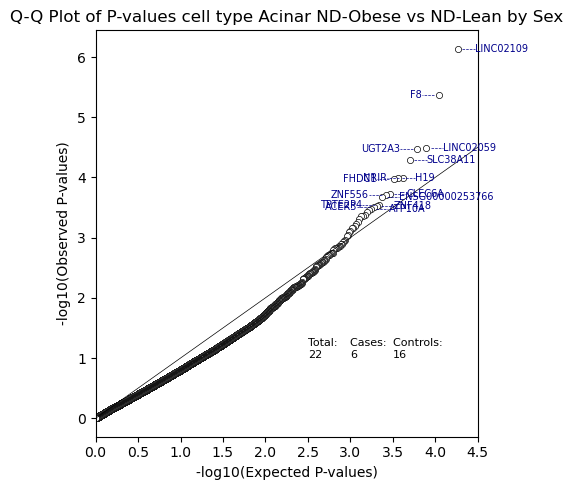

/opt/miniconda3/envs/cfrna/lib/python3.12/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "Diabetes Duration". Fall back to string conversion. The error is: <class 'float'>
  warnings.warn('Error while trying to convert '
R[write to console]:   Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

R[write to console]: estimating size factors

R[write to console]:   Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

R[write to console]: estimating dispe

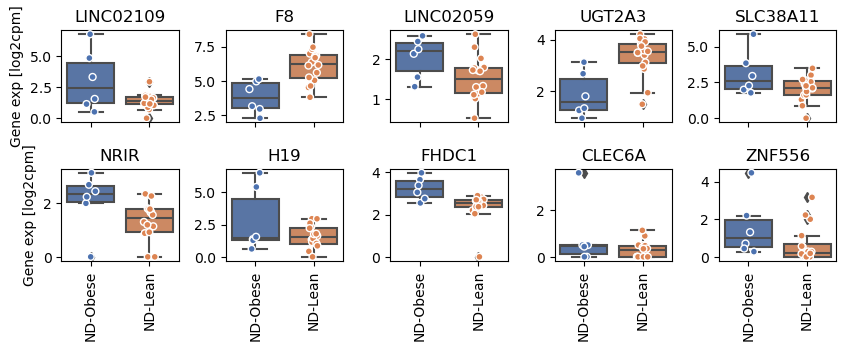

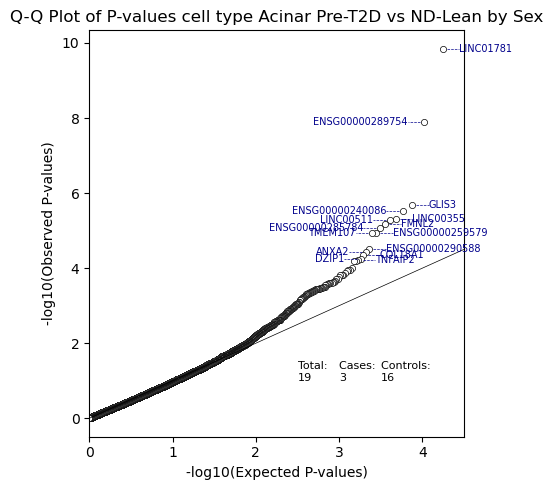

R[write to console]:   Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

R[write to console]: estimating size factors

R[write to console]:   Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

R[write to console]: estimating dispersions

R[write to console]: gene-wise dispersion estimates

R[write to console]: mean-dispersion relationship

R[write to console]:   Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) 

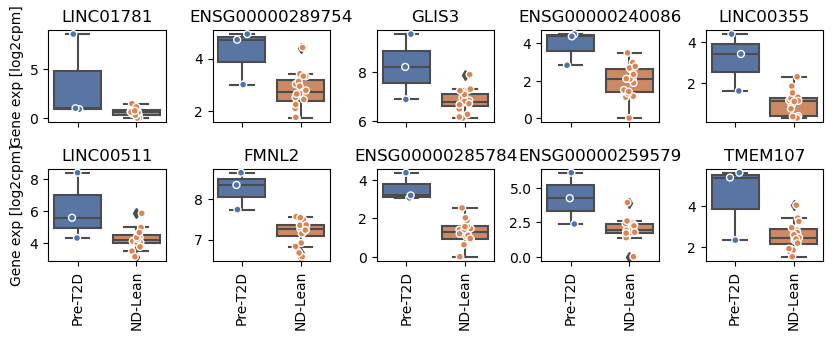

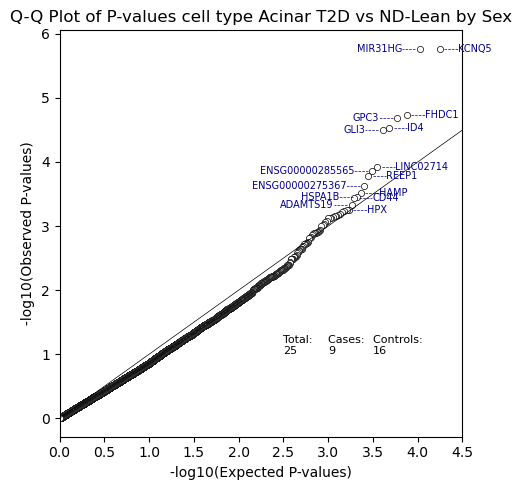

/opt/miniconda3/envs/cfrna/lib/python3.12/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "Diabetes Duration". Fall back to string conversion. The error is: Series can only be of one type, or None (and here we have <class 'float'> and <class 'str'>). If happening with a pandas DataFrame the method infer_objects() will normalize data types before conversion.
  warnings.warn('Error while trying to convert '
/opt/miniconda3/envs/cfrna/lib/python3.12/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "HbA1c (%)". Fall back to string conversion. The error is: Series can only be of one type, or None (and here we have <class 'float'> and <class 'str'>). If happening with a pandas DataFrame the method infer_objects() will normalize data types before conversion.
  warnings.warn('Error while trying to convert '
R[write to console]:   Note: levels of factors in the design contain characters other th

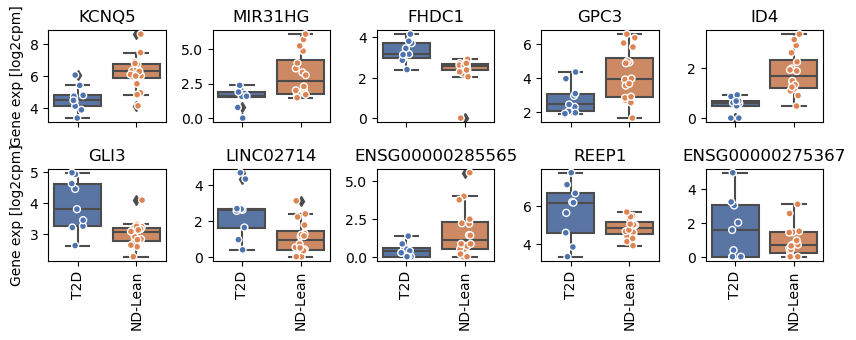

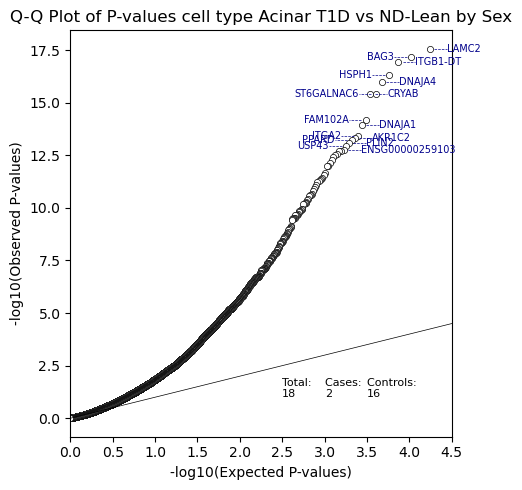

/opt/miniconda3/envs/cfrna/lib/python3.12/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "Diabetes Duration". Fall back to string conversion. The error is: <class 'float'>
  warnings.warn('Error while trying to convert '
R[write to console]:   Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

R[write to console]: estimating size factors

R[write to console]:   Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

R[write to console]: estimating dispe

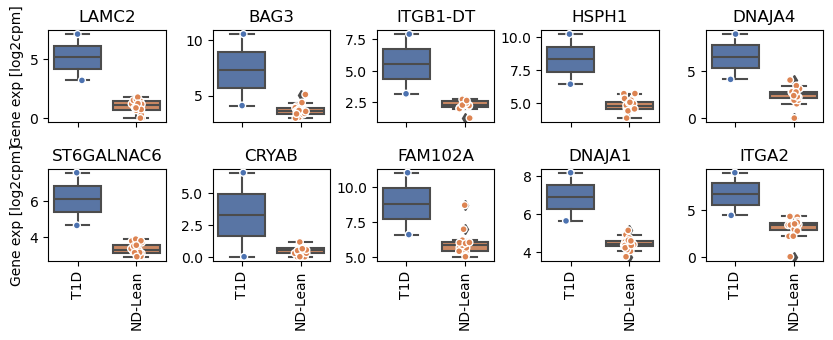

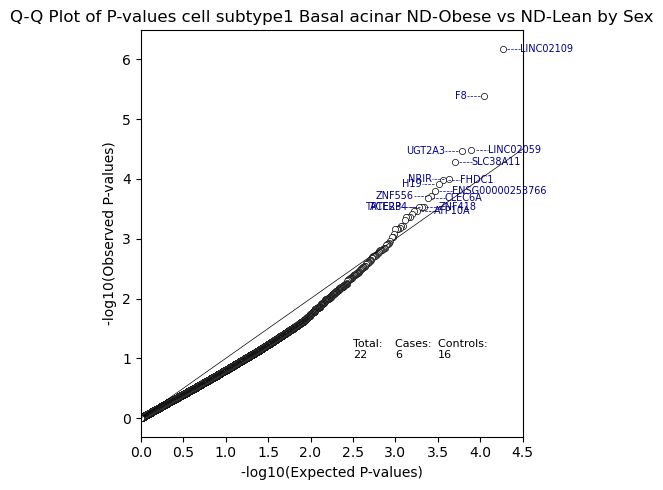

/opt/miniconda3/envs/cfrna/lib/python3.12/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "Diabetes Duration". Fall back to string conversion. The error is: <class 'float'>
  warnings.warn('Error while trying to convert '
R[write to console]:   Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

R[write to console]: estimating size factors

R[write to console]:   Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

R[write to console]: estimating dispe

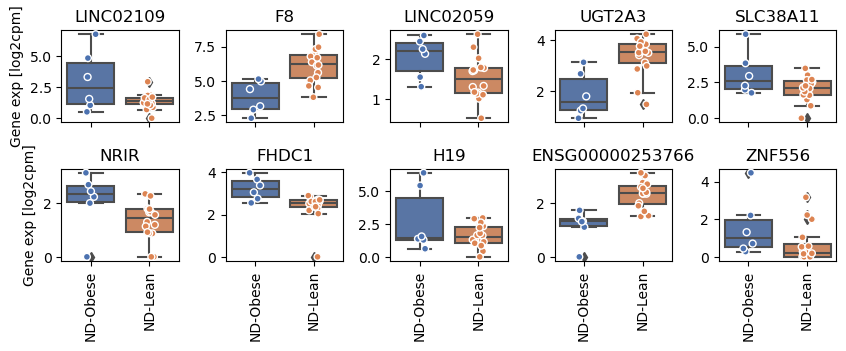

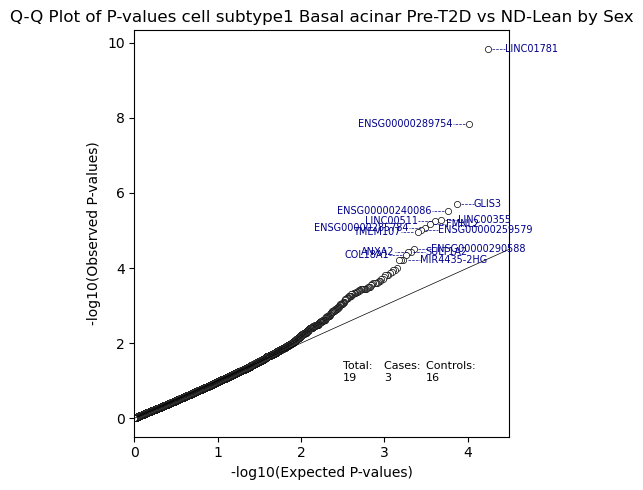

R[write to console]:   Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

R[write to console]: estimating size factors

R[write to console]:   Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

R[write to console]: estimating dispersions

R[write to console]: gene-wise dispersion estimates

R[write to console]: mean-dispersion relationship

R[write to console]:   Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) 

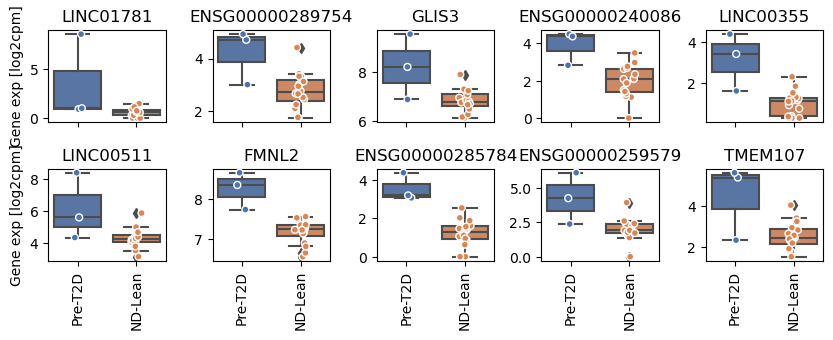

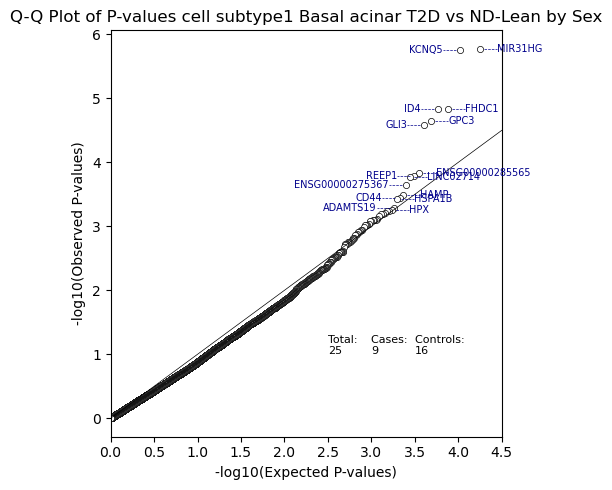

/opt/miniconda3/envs/cfrna/lib/python3.12/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "Diabetes Duration". Fall back to string conversion. The error is: Series can only be of one type, or None (and here we have <class 'float'> and <class 'str'>). If happening with a pandas DataFrame the method infer_objects() will normalize data types before conversion.
  warnings.warn('Error while trying to convert '
/opt/miniconda3/envs/cfrna/lib/python3.12/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "HbA1c (%)". Fall back to string conversion. The error is: Series can only be of one type, or None (and here we have <class 'float'> and <class 'str'>). If happening with a pandas DataFrame the method infer_objects() will normalize data types before conversion.
  warnings.warn('Error while trying to convert '
R[write to console]:   Note: levels of factors in the design contain characters other th

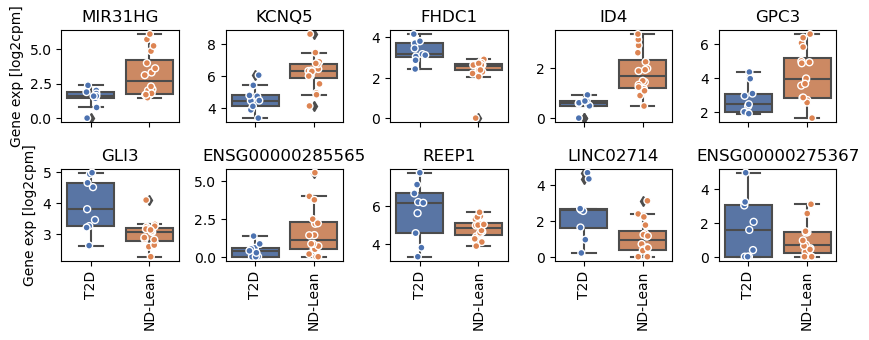

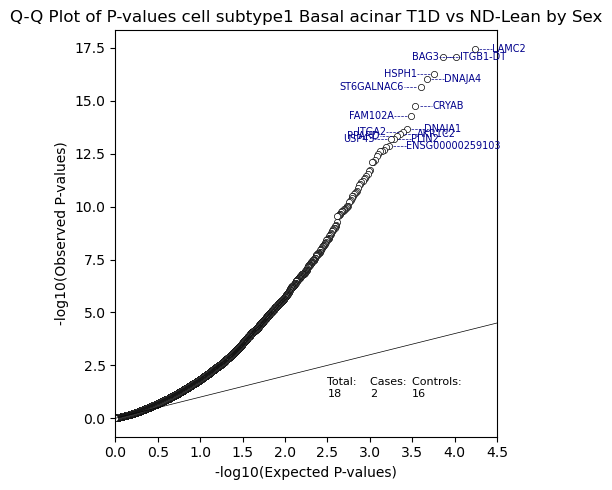

/opt/miniconda3/envs/cfrna/lib/python3.12/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "Diabetes Duration". Fall back to string conversion. The error is: <class 'float'>
  warnings.warn('Error while trying to convert '
R[write to console]:   Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

R[write to console]: estimating size factors

R[write to console]:   Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

R[write to console]: estimating dispe

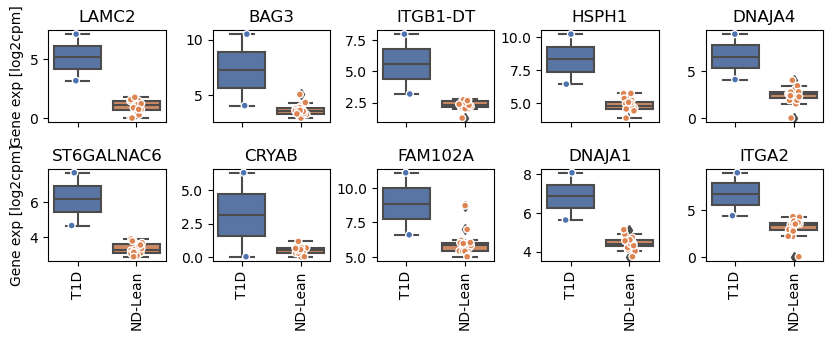

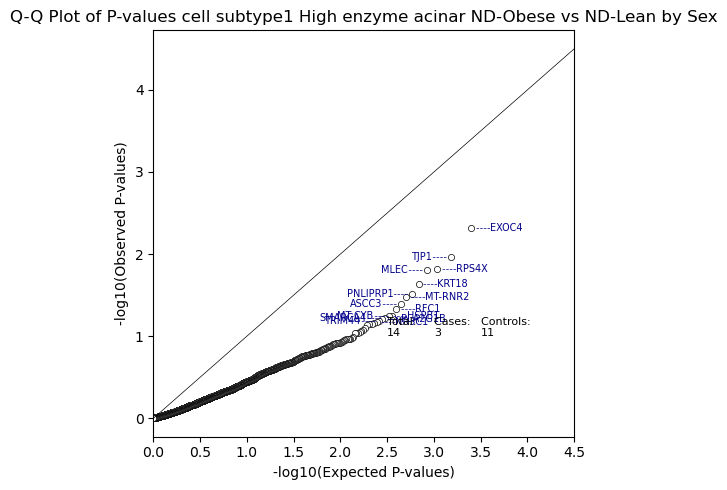

/opt/miniconda3/envs/cfrna/lib/python3.12/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "Diabetes Duration". Fall back to string conversion. The error is: <class 'float'>
  warnings.warn('Error while trying to convert '
R[write to console]:   Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

R[write to console]: estimating size factors

R[write to console]:   Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

R[write to console]: estimating dispe

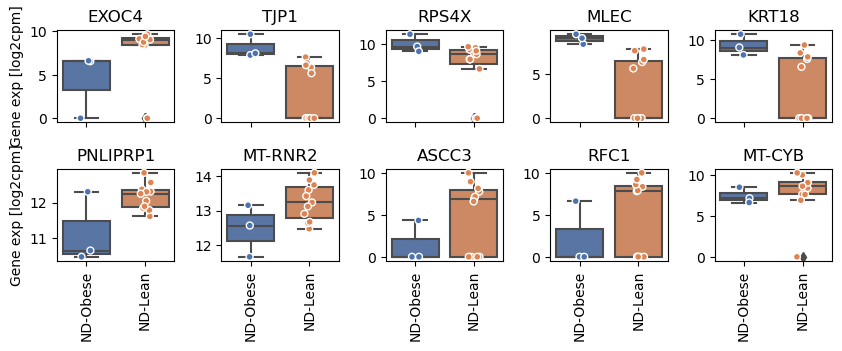

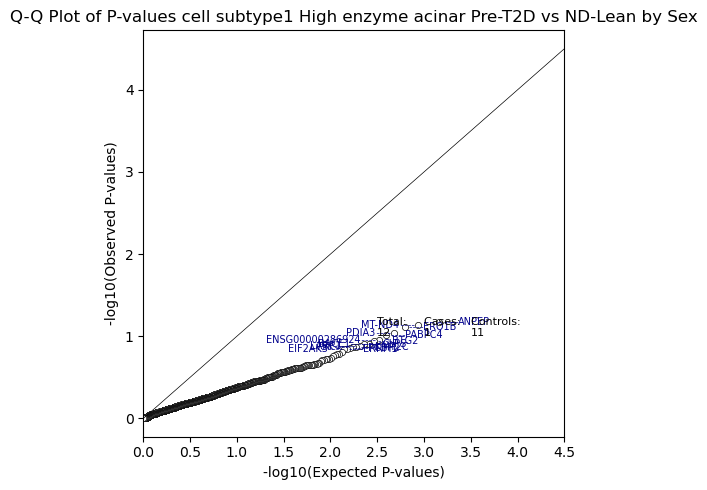

R[write to console]:   Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

R[write to console]: estimating size factors

R[write to console]:   Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

R[write to console]: estimating dispersions

R[write to console]: gene-wise dispersion estimates

R[write to console]: mean-dispersion relationship

R[write to console]: -- note: fitType='parametric', but the dispersion trend was not well captured by the
   function: y = a/x + b, and a local regression fit wa

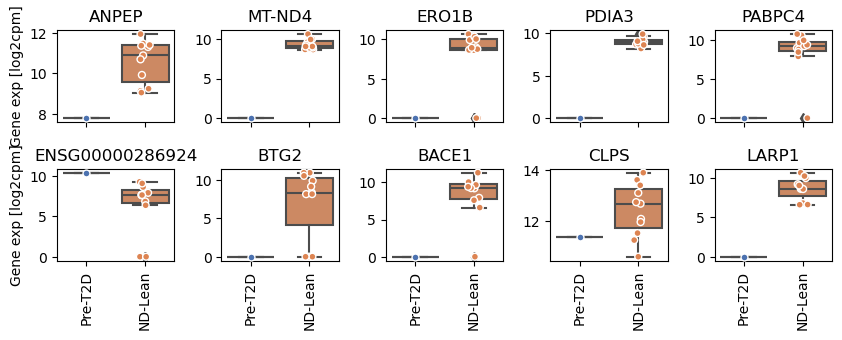

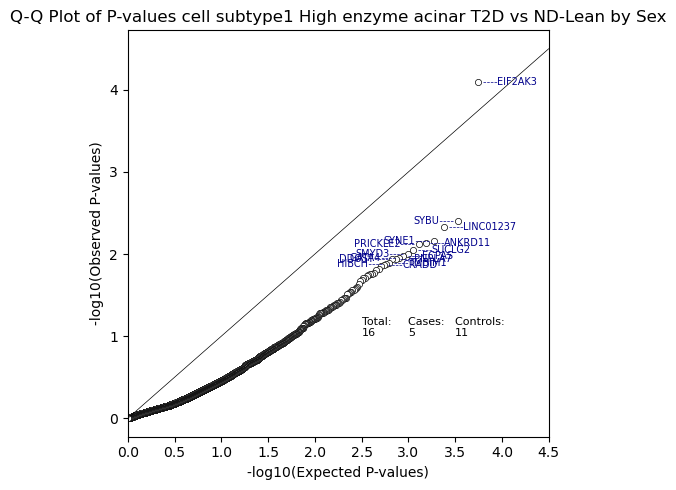

/opt/miniconda3/envs/cfrna/lib/python3.12/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "Diabetes Duration". Fall back to string conversion. The error is: <class 'float'>
  warnings.warn('Error while trying to convert '
R[write to console]:   Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

R[write to console]: estimating size factors

R[write to console]:   Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

R[write to console]: estimating dispe

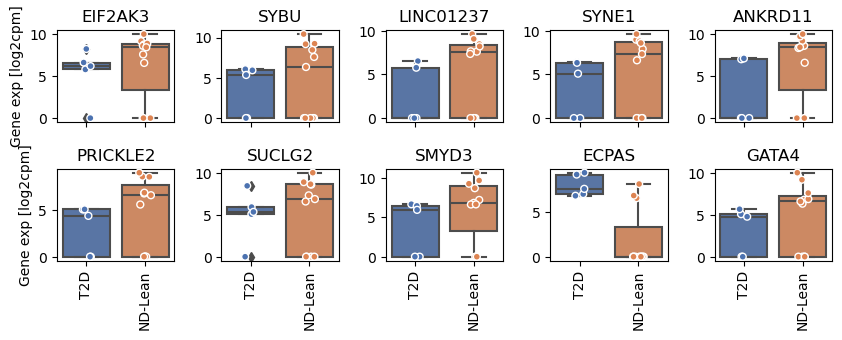

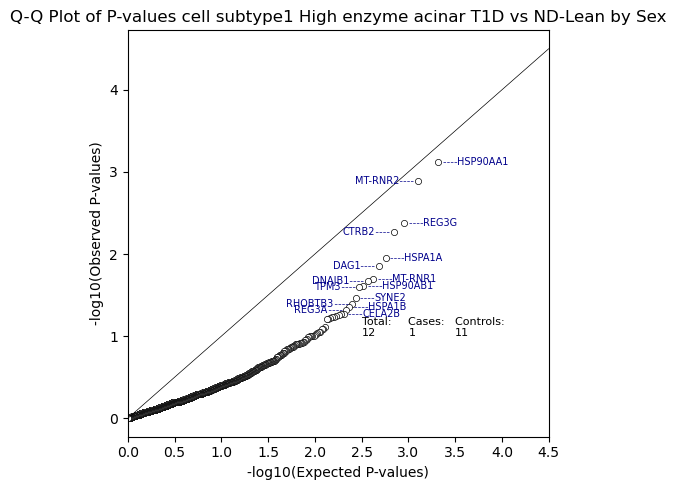

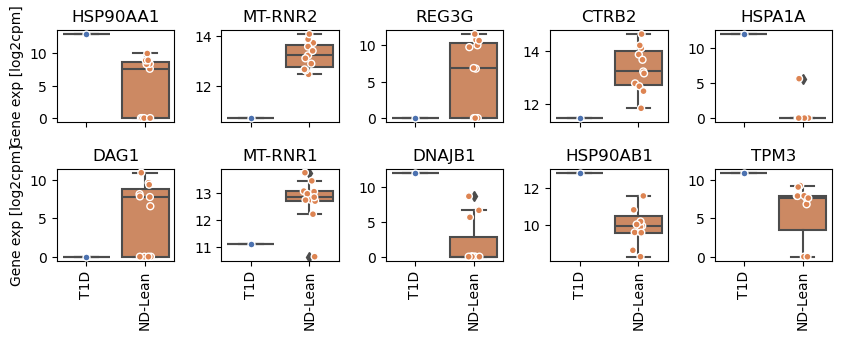

In [8]:
# from rpy2.rinterface_lib.embedded import RRuntimeError  # ✅ Correct import for rpy2 3.x+
# import io
# import sys

# # Define log file name
# current_time = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
# log_filename = f"DESeq_{current_time}.log"

# # Capture output
# log_file = io.StringIO()

# # Redirect standard output (Python)
# sys.stdout = log_file  # Redirect standard output (print statements)
# sys.stderr = log_file  # Redirect errors (stderr)

# code
high_exp_threshold = 3

col = 'group'
ref = 'ND-Lean'

for att in ['cell_type', 'cell_subtype1']: # 
    
    for ct in att_categories[att]:
        data = pd.read_csv(data_folder + f'{att}_{ct}_pseudo_bulk_sum_counts.tsv', 
            sep='\t', index_col=0)
            
        for case in ['ND-Obese', 'Pre-T2D', 'T2D', 'T1D']:
            save_name = f'{att}_{ct}_{case}_vs_{ref}'

            samples = list(set(metadata[metadata[col].isin([case, ref])].index) &
                           set(data.columns))
            
            # filter out genes with highest expression less than 3
            data_filter = data[samples].loc[data[samples].max(axis=1) >= high_exp_threshold]

            n_cases = {}
            n_cases['total_count'] = len(samples)
            n_cases['number_of_cases'] = (metadata.loc[samples][col] == case).sum()
            n_cases['number_of_controls'] = n_cases['total_count'] - n_cases['number_of_cases']
            
            top_n = 10
            name_labels = {1: case, 2: ref}
            data_log2cpm = np.log2(data / data.sum(axis=0) * 1e6 + 1)
            
            if n_cases['number_of_cases'] == 0 or n_cases['number_of_controls'] == 0:
                print(f'⚠️ Skipping DESeq analysis for {save_name} due to a group has 0 samples')
                continue
            else:
                try:
                    # DESeq analysis
                    dds, res = DESeq_analysis(data_filter, metadata, samples, col, ref, 
                                              covariate='Sex', save_name=save_name).values()

                    # dispersion plot with top 10 genes labeled
                    plot_exp_obs_pvalues(res, top_n, n_cases, covariate='Sex', 
                                         save_name=save_name)

                    # boxplot of top 10 genes
                    boxplot_top10_genes(data_log2cpm, metadata, samples, col, ref, res, 
                                        name_labels, save_name, 'Sex')
                except (Exception, RRuntimeError) as e:
                    print(f"⚠️ Skipping sex adjustment for {save_name} due to error: {e}")
                    
                    try:
                        # DESeq analysis
                        dds, res = DESeq_analysis(data_filter, metadata, samples, col, ref, 
                                                  save_name=save_name).values()

                        # dispersion plot with top 10 genes labeled
                        plot_exp_obs_pvalues(res, top_n, n_cases,
                                             save_name=save_name)

                        # boxplot of top 10 genes
                        boxplot_top10_genes(data_log2cpm, metadata, samples, col, ref, res, 
                                            name_labels, save_name)
                    except (Exception, RRuntimeError) as e:
                        print(f"⚠️ Skipping DESeq2 analysis for {save_name} entirely due to repeated errors: {e}")
                
# # Reset standard output and error back to default
# sys.stdout = sys.__stdout__
# sys.stderr = sys.__stderr__

# # Stop redirecting R logs
# ro.r("sink()")

# # Save captured Python logs to file
# with open(log_filename, "w") as f:
#     f.write(log_file.getvalue())

# print(f"✅ Logs saved to {log_filename}")

In [9]:
'''
The following analyses were skipped because one group has 0 samples:

cell_subtype_γ_T1D_vs_ND - Lean
cell_subtype_Plasmablasts-cells_T2D_vs_ND - Lean
cell_subtype_Plasmablasts_T1D_vs_ND - Lean
cell_subtype_T_cells_T1D_vs_ND - Lean
cell_subtype_Mast_cells_ND - Obese_vs_ND - Lean
cell_subtype_Mast_cells_T1D_vs_ND - Lean
cell_subtype_Schwann_T1D_vs_ND - Lean
cell_subtype_Quiescent_stellate_T1D_vs_ND - Lean
'''

'\nThe following analyses were skipped because one group has 0 samples:\n\ncell_subtype_γ_T1D_vs_ND - Lean\ncell_subtype_Plasmablasts-cells_T2D_vs_ND - Lean\ncell_subtype_Plasmablasts_T1D_vs_ND - Lean\ncell_subtype_T_cells_T1D_vs_ND - Lean\ncell_subtype_Mast_cells_ND - Obese_vs_ND - Lean\ncell_subtype_Mast_cells_T1D_vs_ND - Lean\ncell_subtype_Schwann_T1D_vs_ND - Lean\ncell_subtype_Quiescent_stellate_T1D_vs_ND - Lean\n'

# not use sex as covariates

In [10]:
analysis_folder = '../tables/DESeq/DESeq_results'
fig_folder = '../figures/DESeq/DESeq_results/not_by_sex/'

/opt/miniconda3/envs/cfrna/lib/python3.12/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "Diabetes Duration". Fall back to string conversion. The error is: <class 'float'>
  warnings.warn('Error while trying to convert '
R[write to console]:   Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

R[write to console]: estimating size factors

R[write to console]:   Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

R[write to console]: estimating dispe

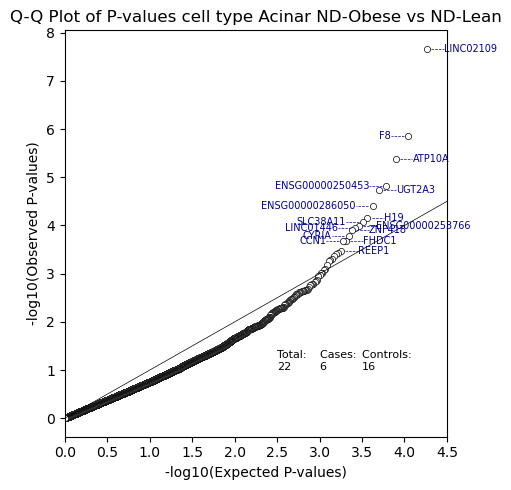

/opt/miniconda3/envs/cfrna/lib/python3.12/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "Diabetes Duration". Fall back to string conversion. The error is: <class 'float'>
  warnings.warn('Error while trying to convert '
R[write to console]:   Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

R[write to console]: estimating size factors

R[write to console]:   Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

R[write to console]: estimating dispe

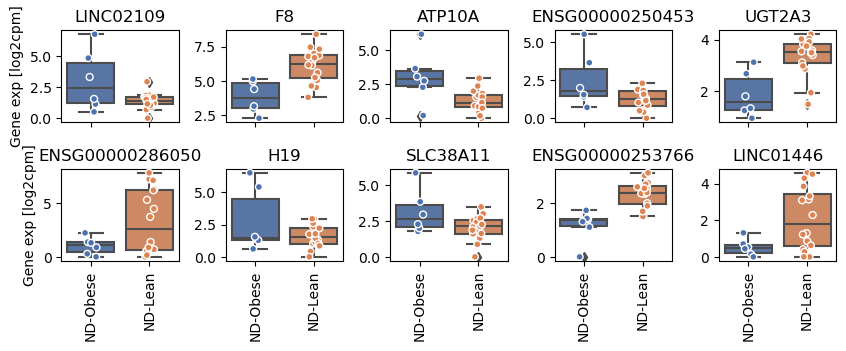

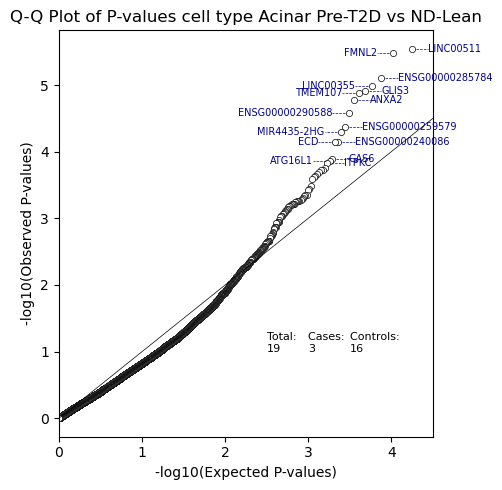

R[write to console]:   Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

R[write to console]: estimating size factors

R[write to console]:   Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

R[write to console]: estimating dispersions

R[write to console]: gene-wise dispersion estimates

R[write to console]: mean-dispersion relationship

R[write to console]:   Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) 

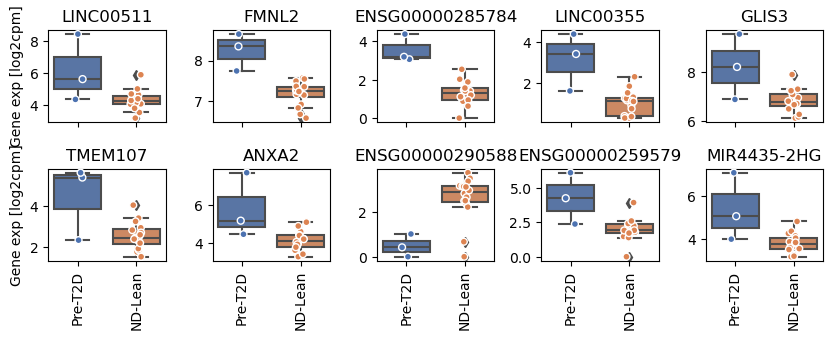

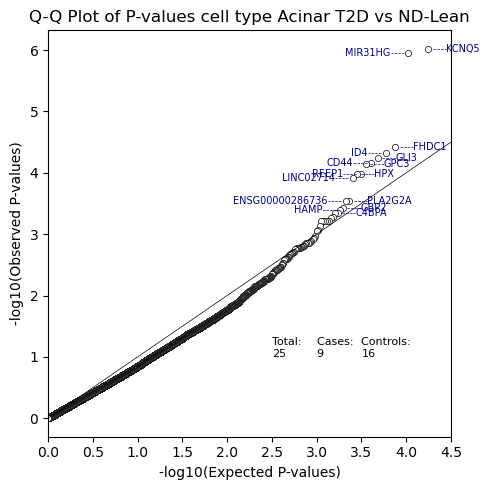

/opt/miniconda3/envs/cfrna/lib/python3.12/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "Diabetes Duration". Fall back to string conversion. The error is: Series can only be of one type, or None (and here we have <class 'float'> and <class 'str'>). If happening with a pandas DataFrame the method infer_objects() will normalize data types before conversion.
  warnings.warn('Error while trying to convert '
/opt/miniconda3/envs/cfrna/lib/python3.12/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "HbA1c (%)". Fall back to string conversion. The error is: Series can only be of one type, or None (and here we have <class 'float'> and <class 'str'>). If happening with a pandas DataFrame the method infer_objects() will normalize data types before conversion.
  warnings.warn('Error while trying to convert '
R[write to console]:   Note: levels of factors in the design contain characters other th

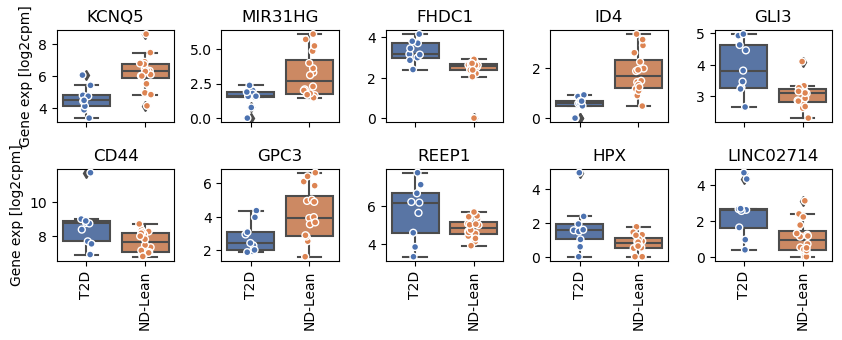

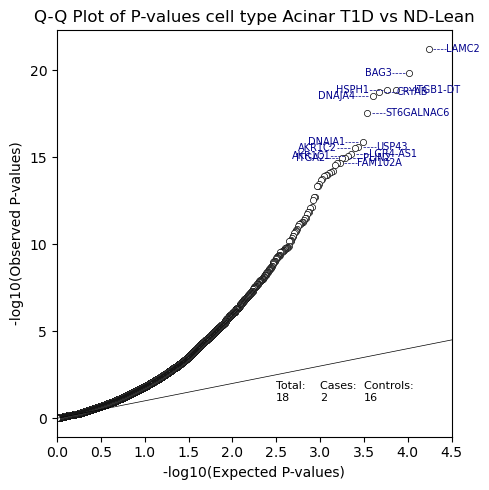

/opt/miniconda3/envs/cfrna/lib/python3.12/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "Diabetes Duration". Fall back to string conversion. The error is: <class 'float'>
  warnings.warn('Error while trying to convert '
R[write to console]:   Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

R[write to console]: estimating size factors

R[write to console]:   Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

R[write to console]: estimating dispe

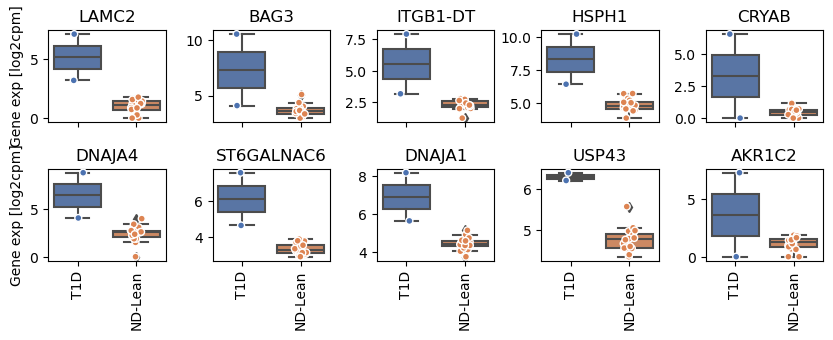

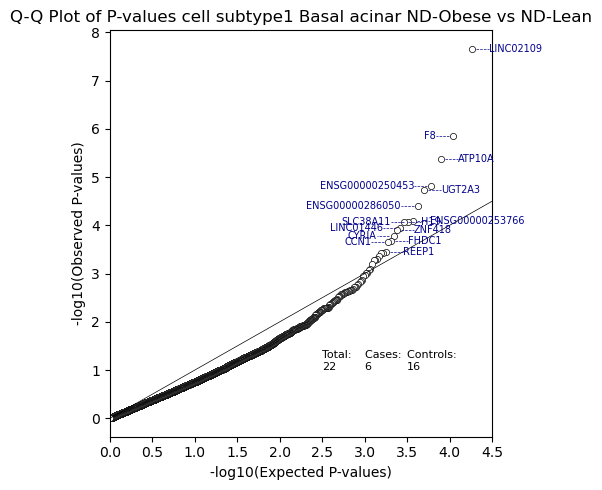

/opt/miniconda3/envs/cfrna/lib/python3.12/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "Diabetes Duration". Fall back to string conversion. The error is: <class 'float'>
  warnings.warn('Error while trying to convert '
R[write to console]:   Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

R[write to console]: estimating size factors

R[write to console]:   Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

R[write to console]: estimating dispe

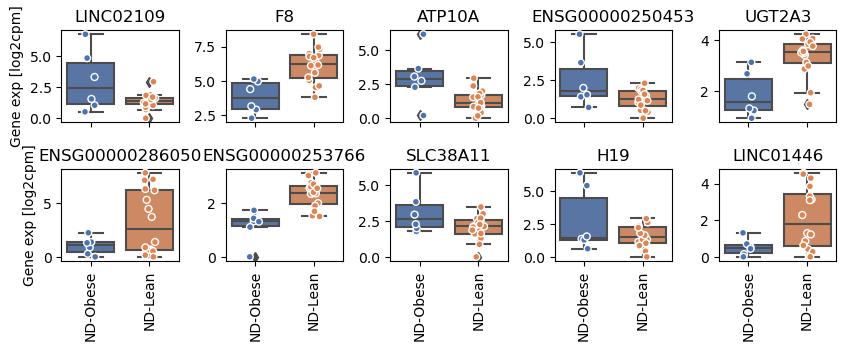

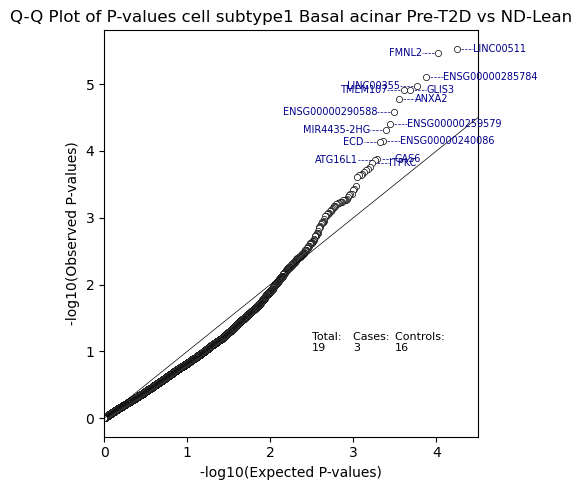

R[write to console]:   Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

R[write to console]: estimating size factors

R[write to console]:   Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

R[write to console]: estimating dispersions

R[write to console]: gene-wise dispersion estimates

R[write to console]: mean-dispersion relationship

R[write to console]:   Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) 

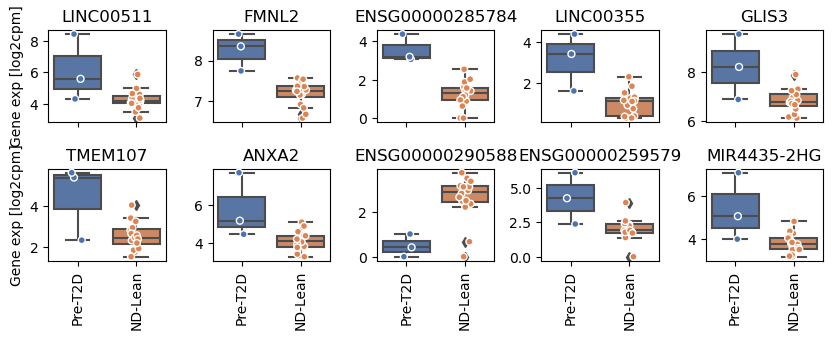

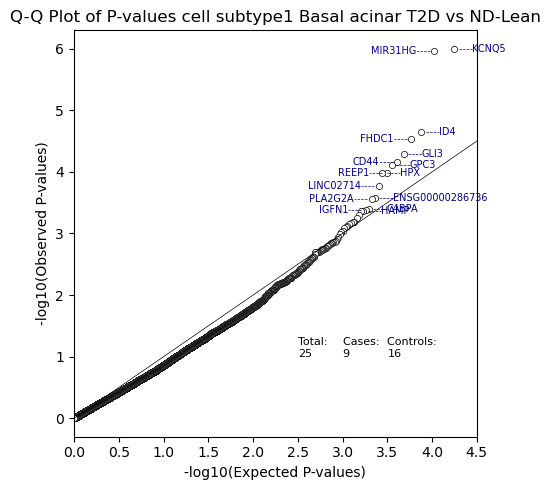

/opt/miniconda3/envs/cfrna/lib/python3.12/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "Diabetes Duration". Fall back to string conversion. The error is: Series can only be of one type, or None (and here we have <class 'float'> and <class 'str'>). If happening with a pandas DataFrame the method infer_objects() will normalize data types before conversion.
  warnings.warn('Error while trying to convert '
/opt/miniconda3/envs/cfrna/lib/python3.12/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "HbA1c (%)". Fall back to string conversion. The error is: Series can only be of one type, or None (and here we have <class 'float'> and <class 'str'>). If happening with a pandas DataFrame the method infer_objects() will normalize data types before conversion.
  warnings.warn('Error while trying to convert '
R[write to console]:   Note: levels of factors in the design contain characters other th

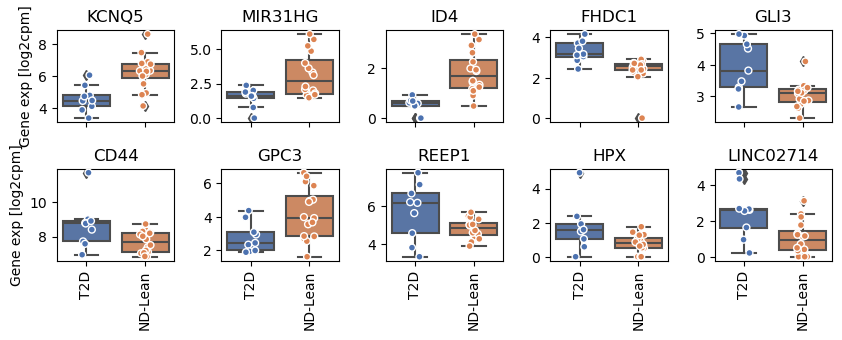

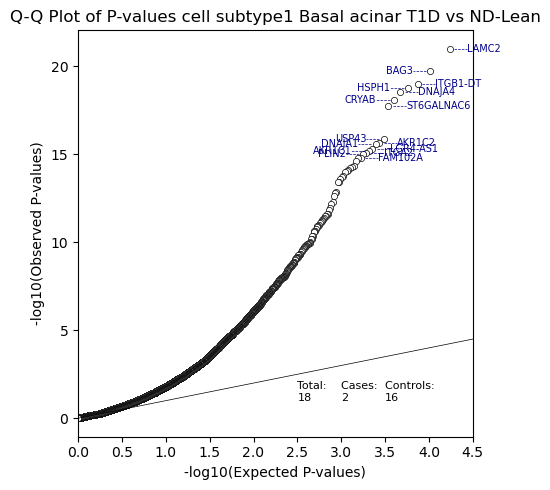

/opt/miniconda3/envs/cfrna/lib/python3.12/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "Diabetes Duration". Fall back to string conversion. The error is: <class 'float'>
  warnings.warn('Error while trying to convert '
R[write to console]:   Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

R[write to console]: estimating size factors

R[write to console]:   Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

R[write to console]: estimating dispe

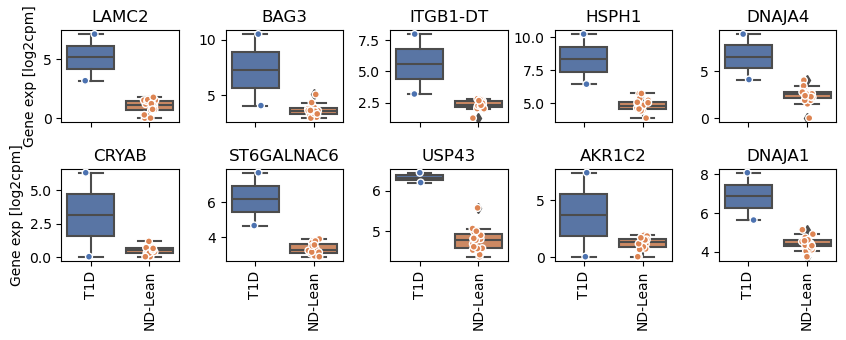

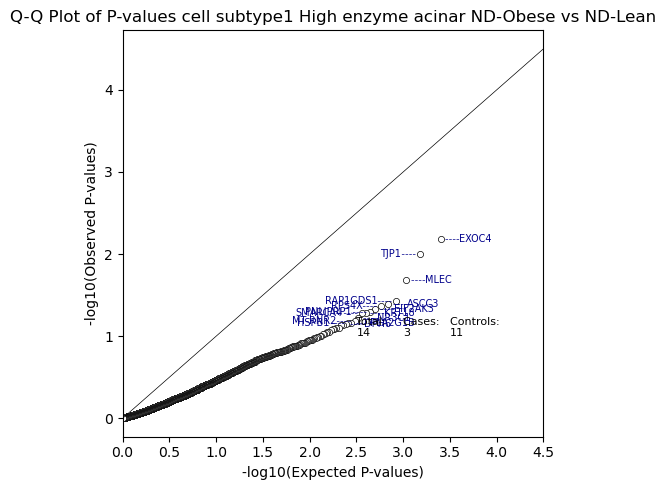

/opt/miniconda3/envs/cfrna/lib/python3.12/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "Diabetes Duration". Fall back to string conversion. The error is: <class 'float'>
  warnings.warn('Error while trying to convert '
R[write to console]:   Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

R[write to console]: estimating size factors

R[write to console]:   Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

R[write to console]: estimating dispe

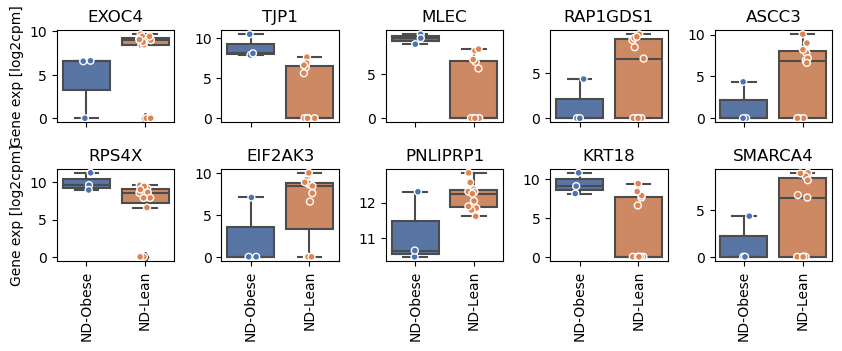

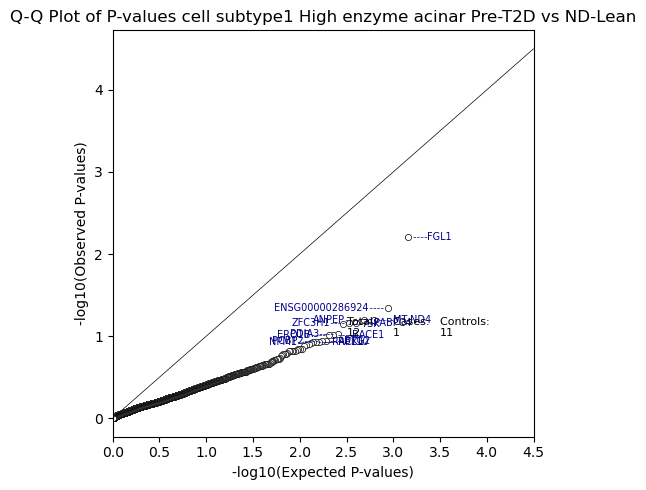

R[write to console]:   Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

R[write to console]: estimating size factors

R[write to console]:   Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

R[write to console]: estimating dispersions

R[write to console]: gene-wise dispersion estimates

R[write to console]: mean-dispersion relationship

R[write to console]:   Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) 

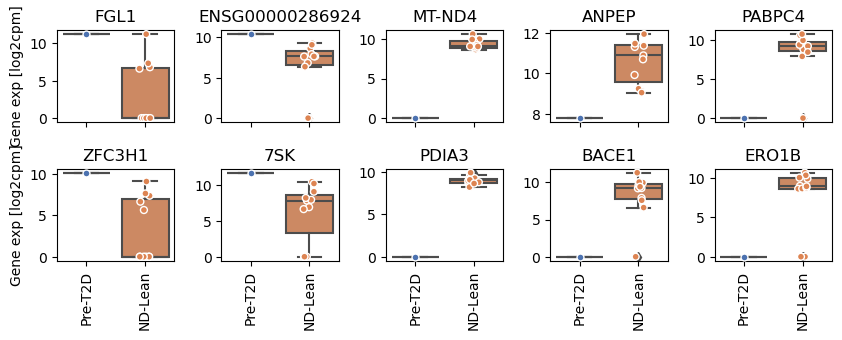

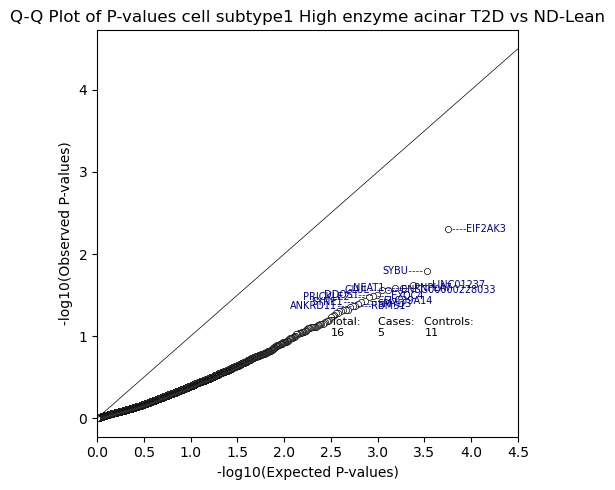

/opt/miniconda3/envs/cfrna/lib/python3.12/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "Diabetes Duration". Fall back to string conversion. The error is: <class 'float'>
  warnings.warn('Error while trying to convert '
R[write to console]:   Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

R[write to console]: estimating size factors

R[write to console]:   Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

R[write to console]: estimating dispe

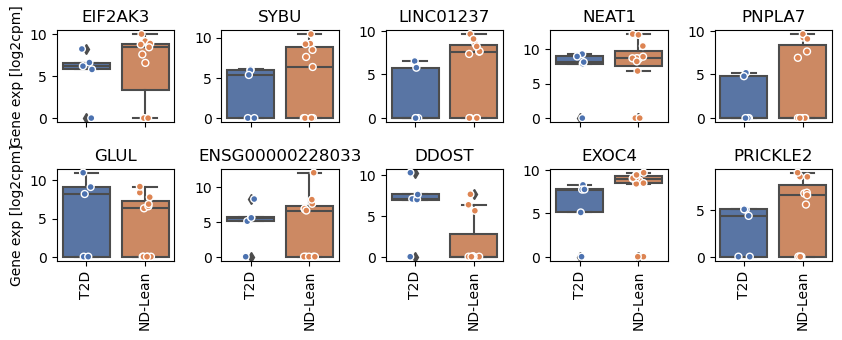

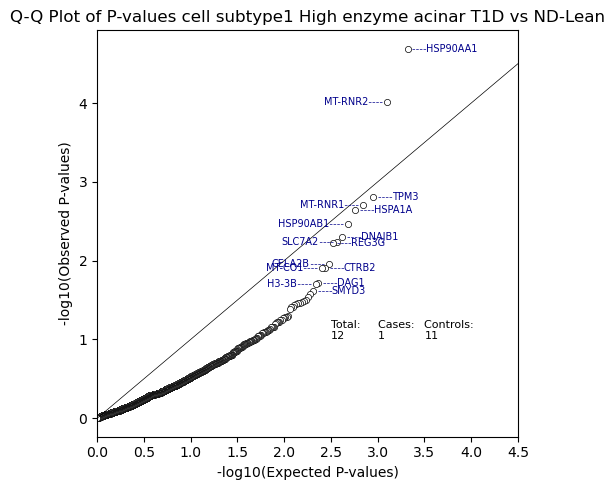

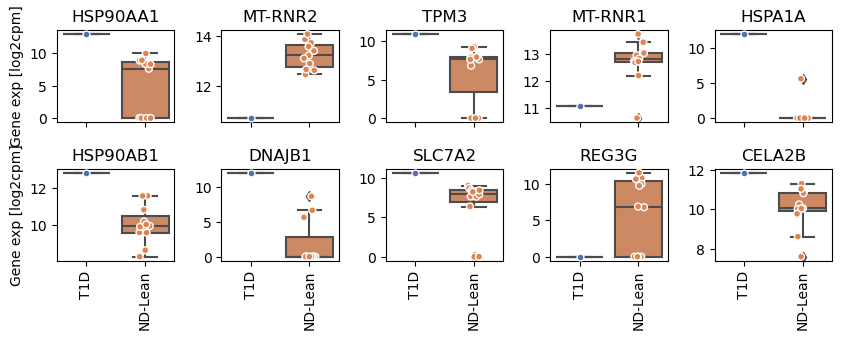

In [11]:
high_exp_threshold = 3

col = 'group'
ref = 'ND-Lean'

for att in ['cell_type', 'cell_subtype1']: # 
    
    for ct in att_categories[att]:
        data = pd.read_csv(data_folder + f'{att}_{ct}_pseudo_bulk_sum_counts.tsv', 
            sep='\t', index_col=0)
            
        for case in ['ND-Obese', 'Pre-T2D', 'T2D', 'T1D']:
            save_name = f'{att}_{ct}_{case}_vs_{ref}'

            samples = list(set(metadata[metadata[col].isin([case, ref])].index) &
                           set(data.columns))
            
            # filter out genes with highest expression less than 3
            data_filter = data[samples].loc[data[samples].max(axis=1) >= high_exp_threshold]

            n_cases = {}
            n_cases['total_count'] = len(samples)
            n_cases['number_of_cases'] = (metadata.loc[samples][col] == case).sum()
            n_cases['number_of_controls'] = n_cases['total_count'] - n_cases['number_of_cases']
            
            top_n = 10
            name_labels = {1: case, 2: ref}
            data_log2cpm = np.log2(data / data.sum(axis=0) * 1e6 + 1)
            
            if n_cases['number_of_cases'] == 0 or n_cases['number_of_controls'] == 0:
                print(f'⚠️ Skipping DESeq analysis for {save_name} due to a group has 0 samples')
                continue
            else:
                try:
                    # DESeq analysis
                    dds, res = DESeq_analysis(data_filter, metadata, samples, col, ref, 
                                              save_name=save_name).values()

                    # dispersion plot with top 10 genes labeled
                    plot_exp_obs_pvalues(res, top_n, n_cases,
                                         save_name=save_name)

                    # boxplot of top 10 genes
                    boxplot_top10_genes(data_log2cpm, metadata, samples, col, ref, res, 
                                        name_labels, save_name)
                except (Exception, RRuntimeError) as e:
                    print(f"⚠️ Skipping DESeq2 analysis for {save_name} entirely due to repeated errors: {e}")

# comparison between subtypes

In [12]:
analysis_folder = '../tables/DESeq/DESeq_subtypes'
fig_folder = '../figures/DESeq/DESeq_subtypes/'

In [13]:
ct_cst_dic = {
    'Acinar': ['Basal_acinar', 'High_enzyme_acinar'], 
#     'Ductal': ['Basal_ductal', 'Inflam_ductal_1', 'Inflam_ductal_2', 'MUC5B+_ductal'], 
#     'Stellate': ['Activated_stellates', 'Quiescent_stellates'],
}

In [14]:
high_exp_threshold = 3

col = 'group'
att = 'cell_subtype1'
ref = 'Rest'

for ct in ['Acinar']: # , 'Ductal', 'Stellate'
    data_ct = pd.read_csv(data_folder + f'cell_type_{ct}_pseudo_bulk_sum_counts.tsv', 
            sep='\t', index_col=0)
    for cst in ct_cst_dic[ct]:
        data_cst = pd.read_csv(data_folder + f'cell_subtype1_{cst}_pseudo_bulk_sum_counts.tsv', 
            sep='\t', index_col=0)
        
        data_group = data_cst.copy()
        data_ref = data_ct - data_cst
        data_ref = data_ref.fillna(0)
        
        for group, name in zip(
            [['ND-Lean', 'ND-Obese', 'Pre-T2D', 'T2D'], 
             ['ND-Lean'], 
             ['ND-Obese'], 
             ['Pre-T2D'], 
             ['T2D'], 
             ['T1D']], 
            ['All', 'ND-Lean', 'ND-Obese', 'Pre-T2D', 'T2D', 'T1D']):
            save_name = f'{ct}_{name}_{cst}_vs_rest'
            group_samples = list(
                set(metadata[metadata[col].isin(group)].index) 
                & set(data_group.columns))
            ref_samples = list(
                set(metadata[metadata[col].isin(group)].index) 
                & set(data_ref.columns))
            
            if len(group_samples) == 0 or len(ref_samples) == 0:
                print(f'⚠️ Skipping DESeq analysis for {save_name} due to a group has 0 samples')
                continue
            else:
                # create a dataframe for DESeq
                group_df = data_group[group_samples]
                group_df.columns = f'{cst}_' + group_df.columns

                ref_df = data_ref[ref_samples]
                ref_df.columns = f'Rest_' + ref_df.columns
                
                data = pd.concat([group_df, ref_df], axis=1).fillna(0)
                
                # filter out genes with highest expression less than 3
                data = data.loc[data.max(axis=1) >= high_exp_threshold]
                
                metadata_tmp = pd.DataFrame(
                    [cst] * group_df.shape[1] + ['Rest'] * ref_df.shape[1], columns = ['group'],
                    index = group_df.columns.tolist() + ref_df.columns.tolist(), )

                # computing
                top_n = 10
                name_labels = {1: cst, 2: ref}
                data_log2cpm = np.log2(data / data.sum(axis=0) * 1e6 + 1)

                samples = data.columns.tolist()

                try:
                    dds, res = DESeq_analysis(data, metadata_tmp, samples, col, ref, 
                                              save_name=save_name).values()
                    plot_exp_obs_pvalues(res, top_n, n_cases=False,
                                         save_name=save_name)
                    boxplot_top10_genes(data_log2cpm, metadata_tmp, samples, col, ref, res, 
                                        name_labels, save_name)
                except (Exception, RRuntimeError) as e:
                    print(f"⚠️ Skipping DESeq2 analysis for {save_name} entirely due to repeated errors: {e}")

R[write to console]: estimating size factors

R[write to console]: Error in estimateSizeFactorsForMatrix(counts(object), locfunc = locfunc,  : 
  every gene contains at least one zero, cannot compute log geometric means

R[write to console]: In addition: 
R[write to console]: There were 25 warnings (use warnings() to see them)
R[write to console]: 



⚠️ Skipping DESeq2 analysis for Acinar_All_Basal_acinar_vs_rest entirely due to repeated errors: Error in estimateSizeFactorsForMatrix(counts(object), locfunc = locfunc,  : 
  every gene contains at least one zero, cannot compute log geometric means



R[write to console]: estimating size factors

R[write to console]: Error in estimateSizeFactorsForMatrix(counts(object), locfunc = locfunc,  : 
  every gene contains at least one zero, cannot compute log geometric means

R[write to console]: In addition: 
R[write to console]: Warning message:

R[write to console]: In DESeqDataSet(se, design = design, ignoreRank) :
R[write to console]: 
 
R[write to console]:  some variables in design formula are characters, converting to factors



⚠️ Skipping DESeq2 analysis for Acinar_ND-Lean_Basal_acinar_vs_rest entirely due to repeated errors: Error in estimateSizeFactorsForMatrix(counts(object), locfunc = locfunc,  : 
  every gene contains at least one zero, cannot compute log geometric means



R[write to console]: estimating size factors

R[write to console]: Error in estimateSizeFactorsForMatrix(counts(object), locfunc = locfunc,  : 
  every gene contains at least one zero, cannot compute log geometric means

R[write to console]: In addition: 
R[write to console]: Warning message:

R[write to console]: In DESeqDataSet(se, design = design, ignoreRank) :
R[write to console]: 
 
R[write to console]:  some variables in design formula are characters, converting to factors



...

⚠️ Skipping DESeq2 analysis for Acinar_Pre-T2D_High_enzyme_acinar_vs_rest entirely due to repeated errors: Error in estimateSizeFactorsForMatrix(counts(object), locfunc = locfunc,  : 
  every gene contains at least one zero, cannot compute log geometric means



R[write to console]: converting counts to integer mode

R[write to console]: estimating size factors

R[write to console]: Error in estimateSizeFactorsForMatrix(counts(object), locfunc = locfunc,  : 
  every gene contains at least one zero, cannot compute log geometric means

R[write to console]: In addition: 
R[write to console]: Warning message:

R[write to console]: In DESeqDataSet(se, design = design, ignoreRank) :
R[write to console]: 
 
R[write to console]:  some variables in design formula are characters, converting to factors

R[write to console]: converting counts to integer mode



⚠️ Skipping DESeq2 analysis for Acinar_T2D_High_enzyme_acinar_vs_rest entirely due to repeated errors: Error in estimateSizeFactorsForMatrix(counts(object), locfunc = locfunc,  : 
  every gene contains at least one zero, cannot compute log geometric means



R[write to console]: estimating size factors

R[write to console]: Error in estimateSizeFactorsForMatrix(counts(object), locfunc = locfunc,  : 
  every gene contains at least one zero, cannot compute log geometric means

R[write to console]: In addition: 
R[write to console]: Warning message:

R[write to console]: In DESeqDataSet(se, design = design, ignoreRank) :
R[write to console]: 
 
R[write to console]:  some variables in design formula are characters, converting to factors



⚠️ Skipping DESeq2 analysis for Acinar_T1D_High_enzyme_acinar_vs_rest entirely due to repeated errors: Error in estimateSizeFactorsForMatrix(counts(object), locfunc = locfunc,  : 
  every gene contains at least one zero, cannot compute log geometric means

